In [1]:
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import numpy as np
import pandas as pd
from scipy.integrate import quad_vec
from scipy.interpolate import interpn
from scipy.special import erf

## Import data

### Boreholes

In [2]:
df_boreholes = pd.read_parquet('./export/boreholes.parquet')

In [3]:
zone_ids = sorted(df_boreholes['zone_id'].unique())
grouped_boreholes = df_boreholes.groupby('zone_id', sort=True)

x = [grouped_boreholes.get_group(zone_id)['x_m'].to_numpy() for zone_id in zone_ids]
y = [grouped_boreholes.get_group(zone_id)['y_m'].to_numpy() for zone_id in zone_ids]
H = [grouped_boreholes.get_group(zone_id)['H_m'].to_numpy() for zone_id in zone_ids]
D = [grouped_boreholes.get_group(zone_id)['D_m'].to_numpy() for zone_id in zone_ids]
r_b = [grouped_boreholes.get_group(zone_id)['r_b_m'].to_numpy() for zone_id in zone_ids]

n_zones = len(zone_ids)

Length, buried depth and radius are equal within a zone.

In [4]:
H = np.array([_H[0] for _H in H])
D = np.array([_D[0] for _D in D])
r_b = np.array([_r_b[0] for _r_b in r_b])

### Segments

In [5]:
df_segments = pd.read_parquet('./export/borehole_segments.parquet')

In [6]:
segments = df_segments.merge(
    df_boreholes[['borehole_id', 'zone_id']],
    on='borehole_id',
    how='left',
).sort_values(['zone_id', 'borehole_id', 'segment_id'])
grouped_segments = segments.groupby('zone_id', sort=True)

z_start = [
    grouped_segments.get_group(zone_id)['z_start_m'].to_numpy().reshape(len(x[index]), -1)
    for index, zone_id in enumerate(zone_ids)
]
z_end = [
    grouped_segments.get_group(zone_id)['z_end_m'].to_numpy().reshape(len(x[index]), -1)
    for index, zone_id in enumerate(zone_ids)
]

Borehole discretization is the same for all boreholes within a zone.

In [7]:
D_segments = [_z_start[0] for _z_start in z_start]
H_segments = [_z_end[0] - _z_start[0] for (_z_end, _z_start) in zip(z_end, z_start)]

### Ground properties

In [8]:
df_ground = pd.read_parquet('./export/ground_properties.parquet')

In [9]:
k_s = df_ground['k_soil_W_mK'].to_numpy().item()
alpha_s = k_s / (df_ground['rho_soil_kg_m3'].to_numpy() * df_ground['c_soil_J_kgK'].to_numpy()).item()
T_g = df_ground['T_undisturbed_K'].to_numpy().item()
T_g_gradient = df_ground['gradient_K_m'].to_numpy().item()
z_start_gradient = df_ground['z_start_gradient'].to_numpy().item()
def undisturbed_ground_temperature(z):
    return T_g + T_g_gradient * np.maximum(z - z_start_gradient, 0.)

### Segment heat rates

In [10]:
df_heat = pd.read_parquet('./export/segment_heat_rates.parquet')

In [11]:
time = np.sort(df_heat['time_end_s'].unique())
segment_ids = np.sort(df_heat['segment_id'].unique())

q_by_zone_segment = (
    df_heat.groupby(['time_end_s', 'zone_id', 'segment_id'])['q_segment_W_avg']
    .mean()
    .reindex(
        pd.MultiIndex.from_product(
            [time, zone_ids, segment_ids],
            names=['time_end_s', 'zone_id', 'segment_id'],
        )
    )
)
q_segments = q_by_zone_segment.to_numpy().reshape(
    len(time), len(zone_ids), len(segment_ids)
)

## Visualize borefield

### Top view

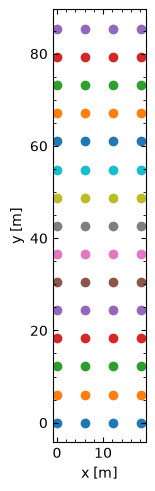

In [12]:
fig, ax = plt.subplots(constrained_layout=True)
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_aspect('equal', adjustable='box')
ax.tick_params(
	axis='both', which='both', direction='in',
	bottom=True, top=True, left=True, right=True)
for i, (_x, _y) in enumerate(zip(x, y)):
        ax.scatter(_x, _y, label=f'Zone {zone_ids[i]}')
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

### Side view

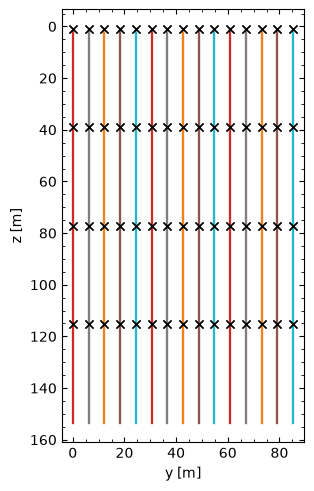

In [13]:
fig, ax = plt.subplots(constrained_layout=True)
ax.set_xlabel('y [m]')
ax.set_ylabel('z [m]')
ax.set_aspect('equal', adjustable='box')
ax.invert_yaxis()
ax.tick_params(
	axis='both', which='both', direction='in',
	bottom=True, top=True, left=True, right=True)
for i, (_y, _D, _H, _D_segments) in enumerate(zip(y, D, H, D_segments)):
        _y_coords = np.tile(_y, (2, 1))
        _z_coords = np.array([_D, _D + _H])
        ax.plot(_y_coords, _z_coords, label=f'Zone {zone_ids[i]}')
        ax.plot(_y_coords.T, _D_segments, 'kx')
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

## Evaluation of the temperature field on a horizontal layer

### Parameters

Note: evaluating a vertical plane is slower than a horizontal layer (roughly 20 min vs 5 min on the original author's machine), because depth coordinates are not clustered/reduced for the thermal response factor evaluation, only horizontal radial distances are (see `_cluster_distances` below). A vertical cut is added further down, after the horizontal example.

In [14]:
x_min = df_boreholes['x_m'].min() - 15.0
x_max = df_boreholes['x_m'].max() + 15.0
y_min = df_boreholes['y_m'].min() - 15.0
y_max = df_boreholes['y_m'].max() + 15.0

num_x = 71
num_y = 181
x_T, y_T = np.meshgrid(
    np.linspace(x_min, x_max, num_x),
    np.linspace(y_min, y_max, num_y),
)
z_T = D[0] + H[0] / 2

p_T = np.stack([x_T, y_T, z_T * np.ones_like(x_T)], axis=-1).reshape(-1, 3)

In [16]:
T_g_T = undisturbed_ground_temperature(z_T)

### Finite line source solution

In [17]:
def _cluster_distances(r, relative_tolerance):
    """Return representative distances and their group labels."""
    r = np.asarray(r, dtype=float)
    order = np.argsort(r)
    sorted_r = r[order]
    labels = np.empty(len(r), dtype=int)
    representatives = []

    for sorted_index, distance in enumerate(sorted_r):
        if not representatives or distance > representatives[-1] * (1.0 + relative_tolerance):
            representatives.append(distance)
        labels[order[sorted_index]] = len(representatives) - 1

    return np.asarray(representatives), labels


def zoned_finite_line_source_to_points_reduced_vector(
        p_points, t, alpha, p_boreholes, H, D, r_b,
        relative_tolerance=1e-2, adiabatic_surface=False):
    """Integrate a reduced distance vector and expand it to all points."""
    p_points = np.asarray(p_points, dtype=float)
    p_boreholes = np.asarray(p_boreholes, dtype=float)
    t = np.atleast_1d(np.asarray(t, dtype=float))
    H = np.atleast_1d(np.asarray(H, dtype=float))
    D = np.atleast_1d(np.asarray(D, dtype=float))
    if relative_tolerance < 0:
        raise ValueError('relative_tolerance must be non-negative')

    distances = np.maximum(
        np.hypot(
            p_points[:, None, 0] - p_boreholes[None, :, 0],
            p_points[:, None, 1] - p_boreholes[None, :, 1],
        ),
        r_b,
    )

    reduced_distances = []
    reduced_depths = []
    point_weights = np.zeros((len(p_points), 0))
    for depth in np.unique(p_points[:, 2]):
        point_indices = np.flatnonzero(p_points[:, 2] == depth)
        representatives, labels = _cluster_distances(
            distances[point_indices].ravel(), relative_tolerance
        )
        weights = np.zeros((len(point_indices), len(representatives)))
        np.add.at(weights, (np.repeat(np.arange(len(point_indices)), distances.shape[1]), labels), 1.0)
        point_weights = np.pad(
            point_weights,
            ((0, 0), (0, len(representatives))),
        )
        point_weights[point_indices, -len(representatives):] = weights
        reduced_distances.extend(representatives)
        reduced_depths.extend([depth] * len(representatives))

    reduced_distances = np.asarray(reduced_distances)
    reduced_depths = np.asarray(reduced_depths)
    reduced_count = len(reduced_distances)

    def _integrand(s):
        decay = np.exp(-(reduced_distances * s) ** 2) / s
        real = erf((D[None, :] + H[None, :] - reduced_depths[:, None]) * s)
        real -= erf((D[None, :] - reduced_depths[:, None]) * s)
        mirror = erf((D[None, :] + H[None, :] + reduced_depths[:, None]) * s)
        mirror -= erf((D[None, :] + reduced_depths[:, None]) * s)
        surface_term = real + mirror if adiabatic_surface else real - mirror
        return (0.5 * decay[:, None] * surface_term).reshape(reduced_count * len(H))

    lower_limits = 1.0 / np.sqrt(4.0 * alpha * t)
    h_reduced = np.stack(
        [quad_vec(_integrand, lower_limit, np.inf)[0] for lower_limit in lower_limits],
        axis=0,
    ).reshape(len(t), reduced_count, len(H))
    return np.einsum('pg,tgs->tps', point_weights, h_reduced)

In [18]:
time_reduced = []
_t = 0.
_dt = time[0]
_level = 0
_cells_per_level = 6
_cells_in_level = 0
while _t < time[-1]:
    _t += _dt
    time_reduced.append(_t)
    _cells_in_level += 1
    if _cells_in_level >= _cells_per_level:
        _level += 1
        _cells_per_level *= 2
        _cells_in_level = 0
        _dt *= 2
time_reduced = np.array(time_reduced)

In [19]:
relative_tolerance = 1e-2
h_zoned_reduced_vector = [
    zoned_finite_line_source_to_points_reduced_vector(
        p_T,
        time_reduced,
        alpha_s,
        np.stack([_x, _y], axis=-1),
        _H_segments,
        _D_segments,
        _r_b,
        relative_tolerance=relative_tolerance,
    )
    for _x, _y, _H_segments, _D_segments, _r_b in zip(
        x, y, H_segments, D_segments, r_b
    )
]

In [20]:
h_zoned = [interpn((time_reduced,), _h_zoned, time, method='linear') for _h_zoned in h_zoned_reduced_vector]

In [21]:
kappa_zoned = [
    np.diff(_h, axis=0, prepend=np.zeros((1, _h.shape[1], _h.shape[2]))) / (2 * np.pi * k_s * _H_segments)
    for _h, _H_segments in zip(h_zoned, H_segments)
]

### Temperature field at prescribed time index

In [ ]:
# time step to visualize: 600 steps before the end of the simulation
index = len(time) - 600

In [ ]:
# superpose each zone's segment step-responses up to `index` (see Temperature_visualization.md, section 2)
T = np.ravel(T_g_T)
for _kappa_zoned, _q_segments in zip(kappa_zoned, q_segments.swapaxes(0, 1)):
    T = T + np.einsum('tps,ts->p', _kappa_zoned[:index+1], _q_segments[index::-1])

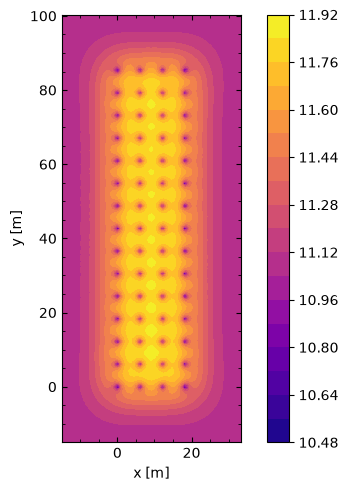

In [25]:
fig, ax = plt.subplots(constrained_layout=True)
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_aspect('equal', adjustable='box')
ax.tick_params(
	axis='both', which='both', direction='in',
	bottom=True, top=True, left=True, right=True)
ax.contourf(x_T, y_T, T.reshape(x_T.shape) - 273.15, levels=20, cmap='plasma')
cb = fig.colorbar(ax.collections[0], ax=ax)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

### Animation over time

Same horizontal slice as above, played back as an animation. At most
`max_frames` time steps, evenly spaced, are evaluated (with only 90 steps in
this simulation, that currently means every step) — this keeps both the
computation and the resulting file size manageable for much longer
simulations too. The color scale is fixed to the min/max over the whole
simulation so colors stay comparable from frame to frame.

In [ ]:
# cap the number of animated frames: with long simulations (e.g. years of data)
# evaluating every time step would be both slow (cost grows with time index) and
# produce an unplayably large animation, so pick at most `max_frames` steps, evenly
# spaced in time
max_frames = 150
frame_indices = np.unique(np.linspace(0, len(time) - 1, min(len(time), max_frames)).round().astype(int))
frame_times = time[frame_indices]

# same superposition as above (see cell computing `T`), repeated for every selected time index
T_all = np.empty((len(frame_indices), x_T.size))
T_g_flat = np.ravel(T_g_T)
for frame, i in enumerate(frame_indices):
    T_i = T_g_flat.copy()
    for _kappa_zoned, _q_segments in zip(kappa_zoned, q_segments.swapaxes(0, 1)):
        T_i = T_i + np.einsum('tps,ts->p', _kappa_zoned[:i+1], _q_segments[i::-1])
    T_all[frame] = T_i

T_all_C = T_all.reshape(len(frame_indices), *x_T.shape) - 273.15

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

vmin, vmax = T_all_C.min(), T_all_C.max()

# smaller figure/dpi than the static plot above: the animation embeds one PNG per
# frame in the notebook output, so this keeps the saved file size reasonable
fig, ax = plt.subplots(figsize=(4.5, 5.5), dpi=80, constrained_layout=True)
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_aspect('equal', adjustable='box')
ax.tick_params(
	axis='both', which='both', direction='in',
	bottom=True, top=True, left=True, right=True)
mesh = ax.pcolormesh(x_T, y_T, T_all_C[0], shading='gouraud', cmap='plasma', vmin=vmin, vmax=vmax)
cb = fig.colorbar(mesh, ax=ax)
cb.set_label('Ground temperature [°C]')
title = ax.set_title(f't = {frame_times[0] / 86400:.0f} d')
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

def _update(frame):
    mesh.set_array(T_all_C[frame].ravel())
    title.set_text(f't = {frame_times[frame] / 86400:.0f} d')
    return mesh, title

anim = FuncAnimation(fig, _update, frames=len(frame_indices), interval=200)
plt.close(fig)  # prevent a duplicate static figure from being displayed below
HTML(anim.to_jshtml())